# Machine Learning Methods

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("/Users/goksu/Desktop/DSA210/TERM PROJECT/DSA 210 PROJECT DATA.xlsx")

Initially, the dataset was cleaned and transformed into a suitable format for analysis. Time- related variables such as departure and arrival times were converted into datetime format, and travel durations were standardized in minutes. The final format of the data also provided below.

In [28]:
def time_to_minutes(x):
    if pd.isnull(x):
        return np.nan

    if isinstance(x, str):
        x = pd.to_datetime(x, errors="coerce").time()

    return x.hour * 60 + x.minute + x.second / 60

df["trafic_level"] = df["trafic_level"].astype(str).str.strip()
df["actual_duration_min"] = df["actual_duration"].apply(time_to_minutes)
df["estimated_duration_min"] = df["estimated_duration"].apply(time_to_minutes)

df["departure"] = pd.to_datetime(
    df["departure"].astype(str).str.strip(),
    format="%H:%M:%S",
    errors="coerce"
)

hour = df["departure"].dt.hour
df["rush_hour"] = hour.apply(
    lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0
)

df["distance"] = df["distance"].astype(str).str.replace("km", "", regex=False)
df["distance"] = df["distance"].str.replace(",", ".", regex=False)
df["distance"] = pd.to_numeric(df["distance"], errors="coerce")


df = pd.get_dummies(df, columns=["trafic_level"], drop_first=True)

After preparing the dataset, the features and target variables were defined. Necessary functions for visualizing and evaluating the models were also created, and the dataset was split into training and testing sets before applying the machine learning models.

In [4]:
# MODEL VISUALIZATION FUNCTION

def visualize_model(name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, predictions)

    min_val = min(y_test.min(), predictions.min())
    max_val = max(y_test.max(), predictions.max())

    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(name + " - Actual vs Predicted Duration")
    plt.xlabel("Actual Duration (minutes)")
    plt.ylabel("Predicted Duration (minutes)")
    plt.grid(True)
    plt.show()

# MODEL EVALUATION FUNCTION

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print("\n" + "=" * 40)
    print(name)
    print("=" * 40)
    print("MAE:", round(mae, 2))
    print("RMSE:", round(rmse, 2))
    print("R²:", round(r2, 3))

    print(f"Meaning of R²: This model explains approximately {round(r2 * 100, 1)}% of the variation in actual travel duration.")

    if r2 > 0.7:
        print("Comment: This indicates high predictive power.")
    elif r2 > 0.4:
        print("Comment: This indicates moderate predictive power.")
    else:
        print("Comment: This indicates limited predictive power.")

    print(f"Error interpretation: On average, predictions are off by about {round(mae, 2)} minutes based on MAE.")

# FEATURES AND TARGET

features = [
    "distance",
    "estimated_duration_min",
    "num_lights",
    "rush_hour"
] + [col for col in df.columns if "trafic_level_" in col]

X = df[features]
y = df["actual_duration_min"]

data = pd.concat([X, y], axis=1).dropna()
X = data[features]
y = data["actual_duration_min"]

# TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Linear Regression**


Linear Regression
MAE: 5.46
RMSE: 7.76
R²: 0.914
Meaning of R²: This model explains approximately 91.4% of the variation in actual travel duration.
Comment: This indicates high predictive power.
Error interpretation: On average, predictions are off by about 5.46 minutes based on MAE.


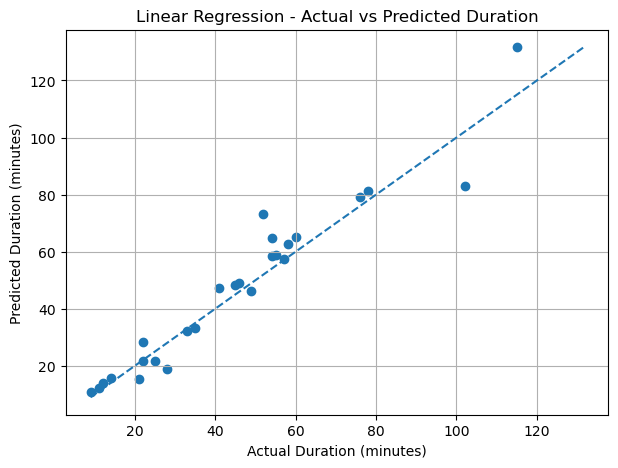

In [5]:
evaluate_model("Linear Regression", LinearRegression())
visualize_model("Linear Regression", LinearRegression())

This model achieved the best performance with an R² score of 0.914, explaining approximately 91.4% of the variance in travel duration. The average prediction error was around 5.46 minutes, indicating strong predictive capability.

**Random Forest**


Random Forest
MAE: 5.36
RMSE: 7.97
R²: 0.909
Meaning of R²: This model explains approximately 90.9% of the variation in actual travel duration.
Comment: This indicates high predictive power.
Error interpretation: On average, predictions are off by about 5.36 minutes based on MAE.


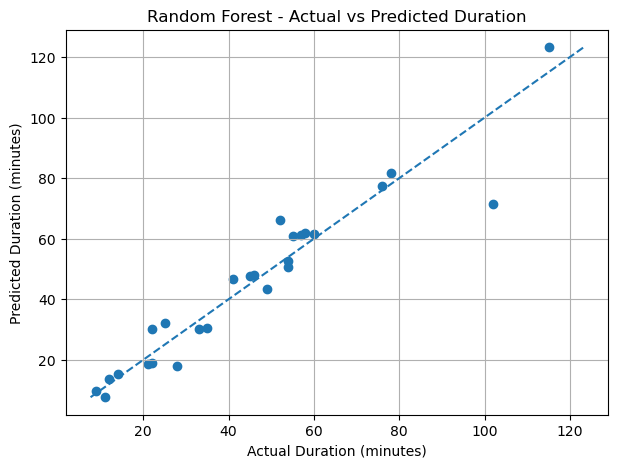

In [6]:
evaluate_model("Random Forest", RandomForestRegressor(random_state=42))
visualize_model("Random Forest", RandomForestRegressor(random_state=42))

This model also performed well with an R² score of 0.909 and a similar error level (~5.36 minutes), showing that non-linear relationships exist but do not significantly outperform linear modeling.

**K-Nearest Neighbours**


KNN
MAE: 5.82
RMSE: 8.34
R²: 0.9
Meaning of R²: This model explains approximately 90.0% of the variation in actual travel duration.
Comment: This indicates high predictive power.
Error interpretation: On average, predictions are off by about 5.82 minutes based on MAE.


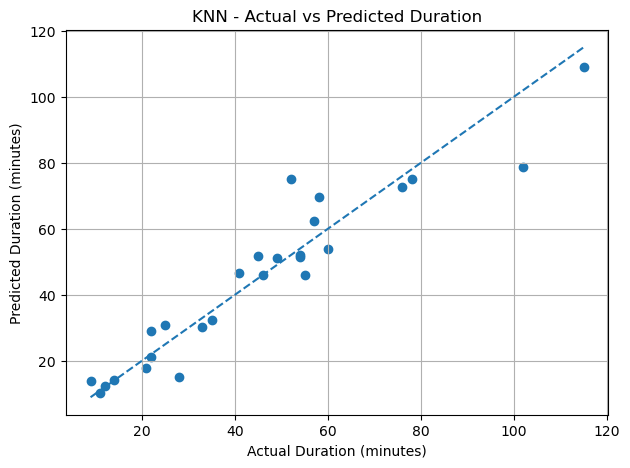

In [7]:
evaluate_model("KNN", KNeighborsRegressor(n_neighbors=5))
visualize_model("KNN", KNeighborsRegressor(n_neighbors=5))

KNN achieved an R² score of 0.90, performing slightly worse than the top models but still demonstrating strong predictive power.

**Decision Tree**


Decision Tree
MAE: 8.0
RMSE: 12.27
R²: 0.784
Meaning of R²: This model explains approximately 78.4% of the variation in actual travel duration.
Comment: This indicates high predictive power.
Error interpretation: On average, predictions are off by about 8.0 minutes based on MAE.


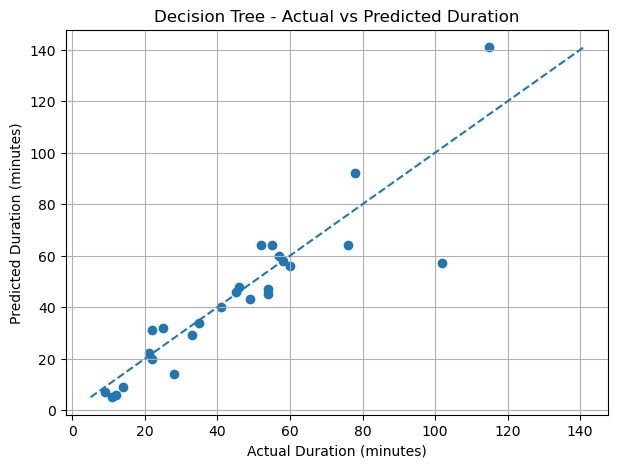

In [8]:
evaluate_model("Decision Tree", DecisionTreeRegressor(random_state=42))
visualize_model("Decision Tree", DecisionTreeRegressor(random_state=42))

This model had the lowest performance (R² = 0.784), suggesting that a single tree structure is not sufficient to capture the complexity of the data.

# General Analysis

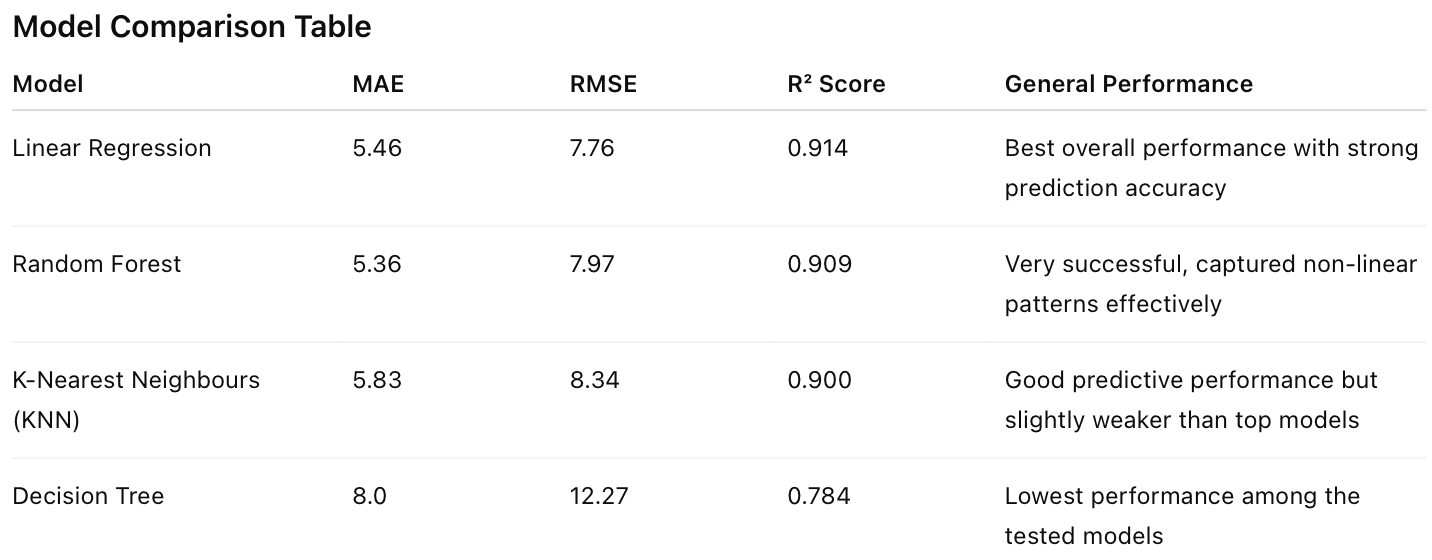

The machine learning results show that most models were able to predict travel duration with relatively high accuracy. Linear Regression achieved the highest R² score, explaining approximately 91.4% of the variation in actual travel duration. This suggests that the relationship between the selected features and travel duration is mostly linear.

Random Forest produced very similar results and slightly lower R² performance compared to Linear Regression. Since Random Forest is capable of capturing more complex and non-linear relationships, its strong performance indicates that some non-linear patterns exist in the dataset. However, the improvement over Linear Regression was not significant, meaning that simpler linear relationships already explain most of the variation in travel duration.

KNN also achieved a high R² score of 0.90, showing that observations with similar traffic and distance characteristics tend to produce similar travel durations. Although its performance was slightly lower than the top-performing models, it still demonstrated strong predictive capability.

Decision Tree had the weakest performance with a noticeably lower R² score and higher error values. This suggests that a single tree structure was not sufficient to fully capture the complexity and variability of the dataset.

Overall, the results indicate that travel duration can be predicted successfully using variables such as distance, traffic level, and estimated duration. The findings also show that relatively simple machine learning models can achieve highly accurate predictions for this dataset.